# Analysis of ejection angle

## 1. Documentation and Imports


Created on 18-02-2021

Author: Valentin Laplaud

A tentative analysis of ejection angle based on vidos from the 09-02-2021

With imageJ, MIN projection where done, and the cone of ejection formed by the various ejected drop was mesured by hand.

In [1]:

# plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn

# numbers handling
import numpy as np
import pandas as pd

import statistics as st # mean median and stuff
import scipy.signal as scpsig # Signal analysis 

# dataframe
import pandas as pd

# my functions
import sys
sys.path.append('../')

import VallapFunc as vf

## 2. Define analysis functions

###  2.1 Loading text files

A general function created to read txt files generated by imageJ, and return a dataframe with the desired columns

/!\ /!\ Now imported as external functions in module VallapFunc /!\ /!\

In [2]:
def LoadImageJResults(FilePath,Columns):
   
        F = open(FilePath,'r') # Open file for reading
        lines = F.readlines() # Read all lines of the file

        Data = pd.DataFrame(data=None)
        
        for c in Columns:
            
            # find the column number in the text file header
            nC = lines[0].rstrip('\n').split('\t').index(c) 

            data = [] # temp data storage
        
            for l in lines[1:]:
                data = np.append(data,np.float(l.rstrip('\n').split('\t')[nC]))  # adds data from the file line by line
                # also removes '\n' from the last columns if present

            Data[c] = data # adding columns to dataframe
        
        return(Data) # return dataframe

    
    

## X. Enter data and run

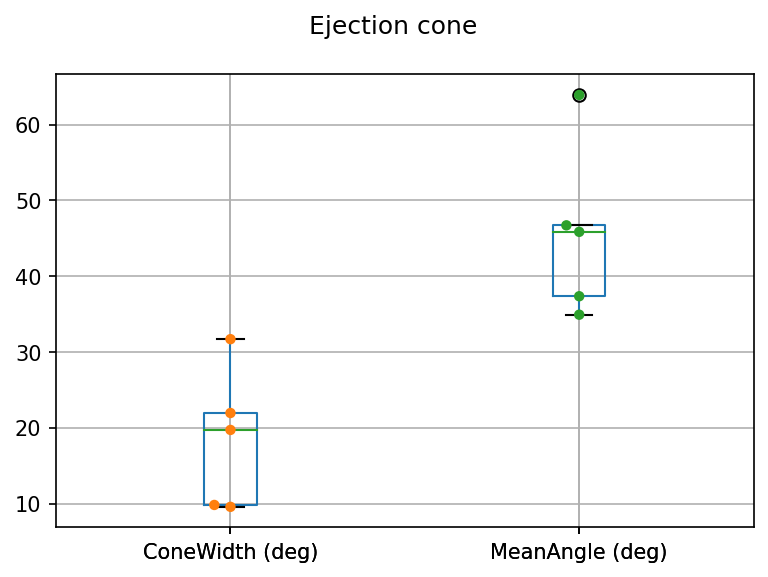

In [3]:
# path to data
P = r'd:\Users\Valentin Laplaud\PostDoc\Data\SplashCups\Manips\21.02.09_CupsSide'

ExpList = ['C2_3','C2_4','C2_6','C2_7','C2_8']


AllData = pd.DataFrame(data=None, columns=['Video', 'MaxAngle', 'MinAngle'])

for e in ExpList:
    Data = vf.LoadImageJResults(P + '\\' + e + '_Cone.txt',['Angle','Length'])
    
    AllData = AllData.append(pd.DataFrame(data=[[e,180-Data['Angle'].min(),180-Data['Angle'].max()]], 
                                          columns=['Video', 'MaxAngle', 'MinAngle'])) # add data
    
    
# Compute angle ratio
AllData['AngleRatio'] = AllData.apply(
lambda row: row['MaxAngle']/row['MinAngle'] , axis = 1)

AllData['ConeWidth (deg)'] = AllData.apply(
lambda row: row['MaxAngle']-row['MinAngle'] , axis = 1)

AllData['MeanAngle (deg)'] = AllData.apply(
lambda row: (row['MaxAngle']+row['MinAngle'])/2 , axis = 1)

vf.df2boxswarm(AllData,['ConeWidth (deg)','MeanAngle (deg)'], suptitle='Ejection cone')





# Test Zone

Text(0.5, 0.98, '')

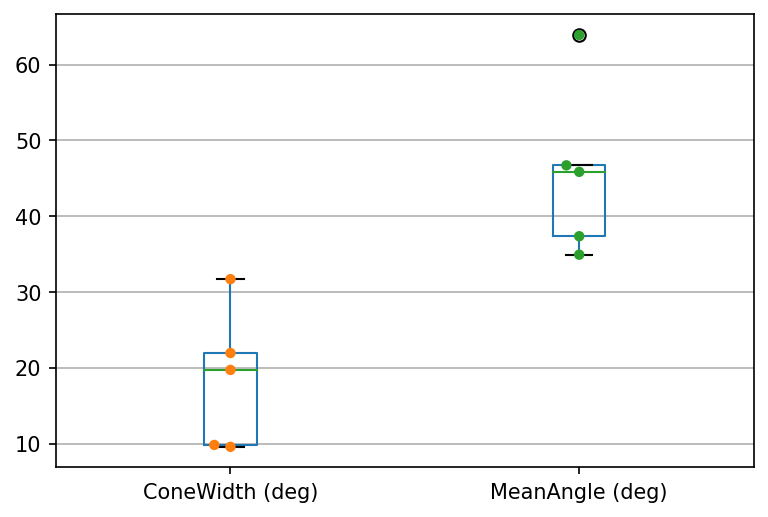

In [4]:
AllData.boxplot(['ConeWidth (deg)', 'MeanAngle (deg)'])
seaborn.swarmplot(x=[0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2],
                  y=np.concatenate(([10], AllData['ConeWidth (deg)'].to_numpy(), AllData['MeanAngle (deg)'].to_numpy())))
plt.xticks(ticks = [1,2], labels = ['ConeWidth (deg)', 'MeanAngle (deg)'])
plt.xlim(0.5,2.5)
fig = plt.gcf()
fig.set_dpi(150)
fig.suptitle(None)



In [5]:
tips = seaborn.load_dataset("tips")

In [6]:
AllData.index

Int64Index([0, 0, 0, 0, 0], dtype='int64')